### **Day 7 Evaluation framework**

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import json

In [2]:
def compute_metrics(y_true, y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return {
        "MAE": float(mae),
        "RMSE": float(rmse),
        "R2": float(r2)
    }

## Prediction vs Truth



In [3]:
def prediction_scatter(
    y_true,
    y_pred,
    title
):

    plt.figure(figsize=(6,6))

    plt.scatter(
        y_true,
        y_pred,
        alpha=0.5
    )

    plt.xlabel("True")

    plt.ylabel("Predicted")

    plt.title(title)

    plt.grid()

    plt.show()

## Error histogram

In [4]:
def error_histogram(
    y_true,
    y_pred,
    title
):

    error = y_pred - y_true

    plt.figure(figsize=(6,4))

    plt.hist(
        error,
        bins=50
    )

    plt.title(title)

    plt.xlabel("Error")

    plt.ylabel("Count")

    plt.show()

## cp comparison

In [5]:
def cp_comparison(
    cp_true,
    cp_pred
):

    plt.figure(figsize=(8,4))

    plt.plot(
        cp_true,
        label="True"
    )

    plt.plot(
        cp_pred,
        label="Predicted"
    )

    plt.legend()

    plt.show()

In [6]:
N = 1000

y_true = np.random.randn(N)

y_pred = y_true + 0.1*np.random.randn(N)

In [7]:
metrics = compute_metrics(
    y_true,
    y_pred
)

metrics

{'MAE': 0.07749769501713827,
 'RMSE': 0.09759335880956388,
 'R2': 0.9901139900982132}

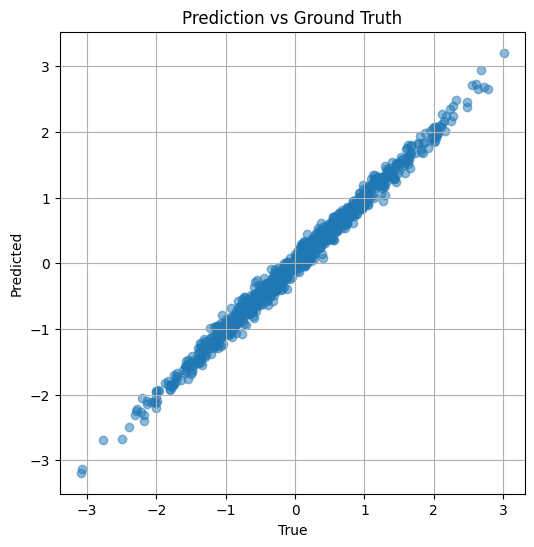

In [8]:
prediction_scatter(
    y_true,
    y_pred,
    "Prediction vs Ground Truth"
)

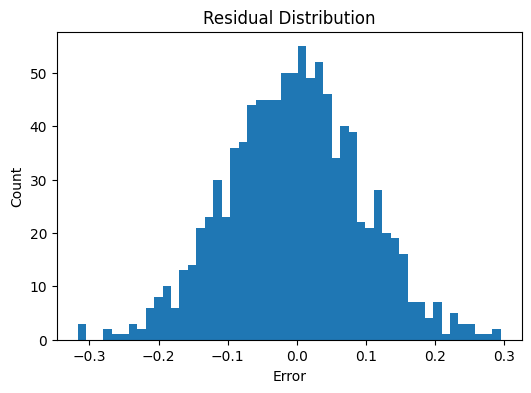

In [9]:
error_histogram(
    y_true,
    y_pred,
    "Residual Distribution"
)


In [10]:
with open(
    "sample_metrics.json",
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )


In [11]:
!cat sample_metrics.json

{
    "MAE": 0.07749769501713827,
    "RMSE": 0.09759335880956388,
    "R2": 0.9901139900982132
}

In [12]:
def benchmark_model(
    y_true,
    y_pred
):

    metrics = compute_metrics(
        y_true,
        y_pred
    )

    prediction_scatter(
        y_true,
        y_pred,
        "Prediction Quality"
    )

    error_histogram(
        y_true,
        y_pred,
        "Error Distribution"
    )

    return metrics

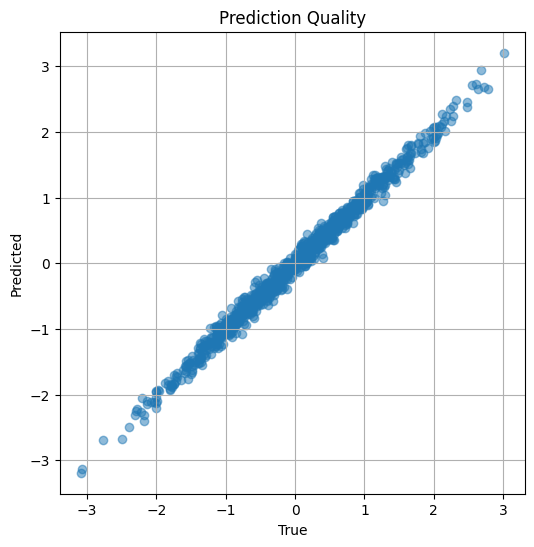

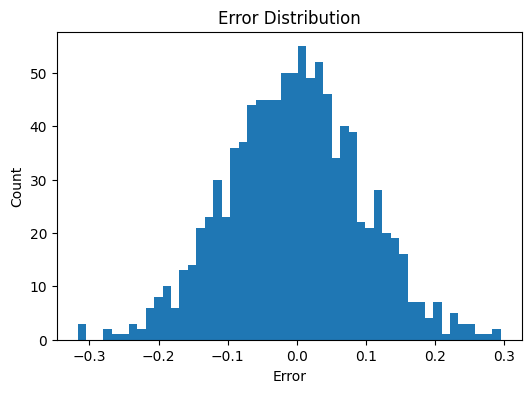

{'MAE': 0.07749769501713827,
 'RMSE': 0.09759335880956388,
 'R2': 0.9901139900982132}

In [13]:
benchmark_model(
    y_true,
    y_pred
)